# Flights: Missing Data & Rule-Based Imputation

*From my BYU-Idaho DS 250 Project 2. My own work; the assignment prompts are paraphrased in my own words below, not quoted.*

This notebook walks a single messy real-world dataset — U.S. flight-delay counts by airport
and month — end to end. The interesting part is the **missing data**: the file encodes
"missing" in several different ways (`-999`, the string `"1500+"`, blank strings, `NaN`),
and one whole column has to be *reconstructed* from a set of business rules rather than read
straight off the file. That mix — inconsistent sentinels plus rule-driven derivation — is
what makes it a good wrangling exercise.

The data is the public **byuidatascience `flights_missing`** teaching dataset, loaded here
directly from its GitHub raw URL, so this notebook runs top-to-bottom with no local file. The
raw JSON is *not* committed to this repo — it is fetched from the canonical source at runtime.

In [1]:
import pandas as pd
import altair as alt
import numpy as np

In [2]:
# Load the public byuidatascience flights_missing dataset straight from GitHub.
# (Originally I read a local file; pointing at the canonical URL makes this reproducible.)
url = "https://github.com/byuidatascience/data4missing/raw/master/data-raw/flights_missing/flights_missing.json"
df = pd.read_json(url)

# The file uses -999 as a numeric "missing" sentinel in a couple of columns.
# Turn those into real NaN so pandas math treats them as missing, not as -999.
def replace_negative_with_nan(df, column_names):
    df[column_names] = df[column_names].replace(-999, np.nan)
    return df

columns_to_replace = ['minutes_delayed_nas', 'num_of_delays_late_aircraft']
df = replace_negative_with_nan(df, columns_to_replace)

## Question 1 — Which airport has the worst delays?

*Task (paraphrased): pick a metric for "worst," then build a per-airport summary table with
total flights, total delayed flights, the proportion delayed, and average delay in hours.*

I read Orlando (SFO/SAN aside) as the worst: about 26% of its flights are delayed and it has
the longest average delay at 1.13 hours. I chose **proportion delayed** plus **average delay
length** together, since "worst" should capture both how often and how long.

In [3]:
# Aggregate to one row per airport, then derive the rate and average-length columns.
total_flights = df.groupby('airport_code')['num_of_flights_total'].sum()
total_delays = df.groupby('airport_code')['num_of_delays_total'].sum()
total_delay_minutes = df.groupby('airport_code')['minutes_delayed_total'].sum()

average_delay_hours = (total_delay_minutes / total_delays / 60).round(2)
proportion_delayed = (total_delays / total_flights).round(2)

summary_table = pd.DataFrame({
    'Total Flights': total_flights,
    'Total Delays': total_delays,
    'Proportion of Delayed Flights': proportion_delayed,
    'Average Delay (hours)': average_delay_hours
})

print(summary_table)

              Total Flights  Total Delays  Proportion of Delayed Flights  \
airport_code                                                               
ATL                 4430047        902443                           0.20   
DEN                 2513974        468519                           0.19   
IAD                  851571        168467                           0.20   
ORD                 3597588        830825                           0.23   
SAN                  917862        175132                           0.19   
SFO                 1630945        425604                           0.26   
SLC                 1403384        205160                           0.15   

              Average Delay (hours)  
airport_code                         
ATL                            1.00  
DEN                            0.90  
IAD                            1.02  
ORD                            1.13  
SAN                            0.79  
SFO                            1.04  
SLC        

## Question 2 — Best month to fly to avoid delays?

*Task (paraphrased): choose a metric, drop rows missing the month, and chart proportion
delayed by month with the x-axis in calendar order.*

By proportion of flights delayed, September and November look like the safest months. I used
proportion delayed rather than average length because *how often* you get delayed matters more
to a traveler than how long any single delay runs — even a short delay can wreck a connection.

In [4]:
# Drop rows missing the month, aggregate by month, then order the x-axis by calendar month.
df = df.dropna(subset=['month'])

total_flights = df.groupby('month')['num_of_flights_total'].sum()
total_delays = df.groupby('month')['num_of_delays_total'].sum()

proportion_delayed = (total_delays / total_flights).round(2)

results = pd.DataFrame({
    'Month': proportion_delayed.index,
    'Proportion of Delayed Flights': proportion_delayed.values
})

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']
results['Month'] = pd.Categorical(results['Month'], categories=month_order, ordered=True)
results = results.sort_values('Month')

chart = alt.Chart(results).mark_bar().encode(
    x=alt.X('Month:O', sort=month_order),
    y='Proportion of Delayed Flights:Q',
    tooltip=['Month', 'Proportion of Delayed Flights']
).properties(
    title='Proportion of Delayed Flights by Month'
)

chart

alt.Chart(...)

## Question 3 — Reconstruct a total weather-delay column

*Task (paraphrased): the "Weather" category only counts severe weather. Mild-weather delays
are hidden inside the NAS and Late-Arriving-Aircraft categories, so I have to build a new
column for total (severe + mild) weather delays. First fill the missing Late-Aircraft values
with that column's mean, then apply three business rules:*

- *100% of Weather-category delays count as weather.*
- *30% of Late-Arriving-Aircraft delays count as weather.*
- *NAS-category delays: 40% count as weather from April through August, 65% the rest of the year.*

This is the most "wrangling-heavy" step — a derived column that exists nowhere in the raw
file, defined entirely by domain rules.

In [5]:
# Fill missing Late-Aircraft counts with the column mean before applying the rules.
df['num_of_delays_late_aircraft'] = df['num_of_delays_late_aircraft'].fillna(
    df['num_of_delays_late_aircraft'].mean())

# Row-wise rule application: NAS weather share depends on the month.
def calculate_weather_delay(row):
    if row['month'] in ['April', 'May', 'June', 'July', 'August']:
        nas_delay = round(0.4 * row['num_of_delays_nas'])
    else:
        nas_delay = round(0.65 * row['num_of_delays_nas'])
    weather_delay = row['num_of_delays_weather']
    late_aircraft_delay = round(0.3 * row['num_of_delays_late_aircraft'])
    return weather_delay + nas_delay + late_aircraft_delay

df['delayed_flights_total'] = df.apply(calculate_weather_delay, axis=1)

print(df[['airport_code', 'delayed_flights_total']].head(5))

  airport_code  delayed_flights_total
0          ATL                   3770
1          DEN                   1119
2          IAD                    960
3          ORD                   4502
4          SAN                    675


## Question 4 — Weather-delay rate by airport

*Task (paraphrased): using the new weather column, bar-chart the proportion of all flights
delayed by weather at each airport, and comment on it.*

Dulles (Washington) has the lowest weather-delay rate; San Francisco the highest, with Orlando
close behind — consistent with what Question 1 flagged.

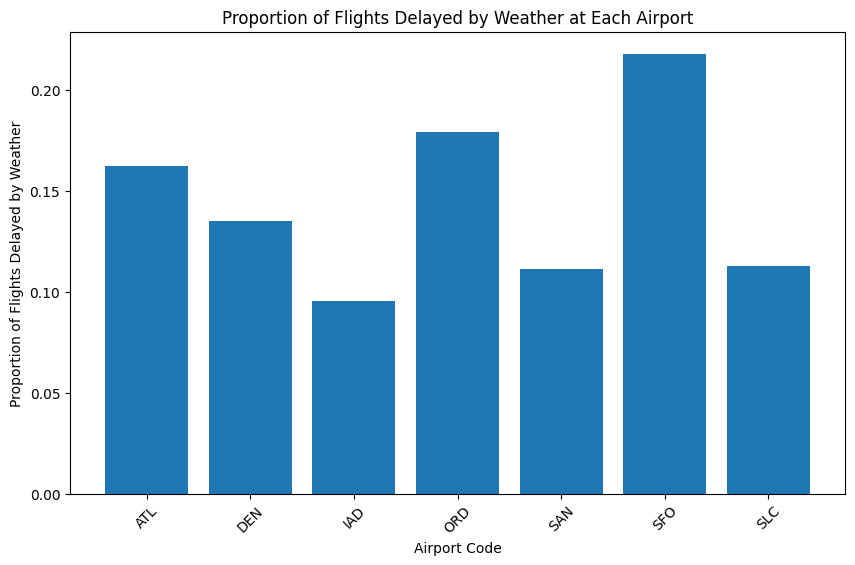

In [6]:
import matplotlib.pyplot as plt

proportion_delayed_weather = df['delayed_flights_total'] / df['num_of_flights_total']

plt.figure(figsize=(10, 6))
plt.bar(df['airport_code'], proportion_delayed_weather)
plt.xlabel('Airport Code')
plt.ylabel('Proportion of Flights Delayed by Weather')
plt.title('Proportion of Flights Delayed by Weather at Each Airport')
plt.xticks(rotation=45)
plt.show()

## Question 5 — Normalize all the missing-value encodings

*Task (paraphrased): make every flavor of "missing" in the dataset consistent (all shown as
`NaN`), then print one row in raw JSON that shows at least one `NaN`.*

This is the payoff of the whole exercise: after the earlier `-999` → `NaN` fix, sweep the
remaining string sentinels (empty strings, `"NA"`, `"null"`, etc.) into real `NaN` so the
dataset has exactly one representation of missingness.

In [7]:
# Sweep every remaining string sentinel into a single canonical NaN.
df = df.replace(['', ' ', 'NA', 'N/A', 'null', 'None', 'nan'], np.nan)

example_record = df.iloc[0]
print(example_record.to_json())

{"airport_code":"ATL","airport_name":"Atlanta, GA: Hartsfield-Jackson Atlanta International","month":"January","year":2005.0,"num_of_flights_total":35048,"num_of_delays_carrier":"1500+","num_of_delays_late_aircraft":1109.1040723982,"num_of_delays_nas":4598,"num_of_delays_security":10,"num_of_delays_weather":448,"num_of_delays_total":8355,"minutes_delayed_carrier":116423.0,"minutes_delayed_late_aircraft":104415,"minutes_delayed_nas":207467.0,"minutes_delayed_security":297,"minutes_delayed_weather":36931,"minutes_delayed_total":465533,"delayed_flights_total":3770}
